## Imports

In [1]:
import wandb
import logging
from tqdm import tqdm
from wandb.sdk.wandb_run import Run
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
import matplotlib.pyplot as plt
import json

## Configuration

In [2]:
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "axes.titlesize": 24,
        "axes.labelsize": 28,
        "xtick.labelsize": 28,
        "ytick.labelsize": 28,
        "legend.fontsize": 24,
    }
)
sns.set_context("talk")

# Define color palette for models (from palette.json)
MODEL_COLORS = {
    "ViT-B-32": "#335c67",  # Dark slate gray
    "ViT-B-16": "#e09f3e",  # Hunyadi yellow
    "ViT-L-14": "#81b29a",  # Cambridge blue
}

# Model name mapping for display
MODEL_LABELS = {
    "ViT-B-32": "ViT-B/32",
    "ViT-B-16": "ViT-B/16",
    "ViT-L-14": "ViT-L/14",
}

# Merger method mapping (full_rank vs low_rank for dual)
MERGER_LABELS = {
    "full_rank": "Full Rank",
    "low_rank": "Low Rank",
}

MERGER_COLORS = {
    "full_rank": "#9e2a2b",   # Auburn
    "low_rank": "#540b0e",    # Chocolate cosmos
}

NUM_TASKS_LIST = [8, 14, 20]

## Fetch Runs from WandB

In [3]:
api = wandb.Api()
entity, project = "gladia", "dual-merging"  # set to your entity and project

In [4]:
def get_runs(entity, project, positive_tags, negative_tags=None):
    """Fetch runs from WandB with specific tags, sorted by timestamp (most recent first)."""
    filters_pos_tags = {"$and": [{"tags": {"$eq": pos_tag}} for pos_tag in positive_tags]}
    
    print(f"Filters: {filters_pos_tags}")
    runs = api.runs(entity + "/" + project, filters=filters_pos_tags, order="-created_at")
    
    print(f"Found {len(runs)} runs matching the criteria.")
    return runs

In [5]:
merger = "iso"
# Fetch all runs tagged with 'sweep'
full_rank = get_runs(entity, project, positive_tags=['full_rank', merger])

low_rank = get_runs(entity, project, positive_tags=['low_rank', merger])

runs = [*full_rank, *low_rank]

Filters: {'$and': [{'tags': {'$eq': 'full_rank'}}, {'tags': {'$eq': 'iso'}}]}
Found 190 runs matching the criteria.
Filters: {'$and': [{'tags': {'$eq': 'low_rank'}}, {'tags': {'$eq': 'iso'}}]}
Found 225 runs matching the criteria.


In [6]:
# 25 (steps) * 3 (architectures) * 3 (benchmarks) * 2 (merging_methods)
# expected_num_runs = 25 * 3 * 3 
# print(f"Expected number of runs: {expected_num_runs}, Retrieved runs: {len(runs)}")

## Parse Run Data

In [7]:
records = []

for i, run in enumerate(tqdm(runs, desc="Processing runs")):
    try:
        # Get normalized accuracy from run history
        col_name = "normalized_acc/test/avg"
        history = run.history(keys=[col_name])
        
        if history.empty:
            print(f"[WARN] Run {i} '{run.name}' has no history for {col_name}")
            continue
            
        norm_acc = history.iloc[-1][col_name]
        
        # Extract model name, num_tasks, rank_type, and scaling_coeff from config
        config = run.config
        tags = run.tags
        
        model_name = None
        num_tasks = None
        rank_type = None  # 'full_rank' or 'low_rank'
        alpha = None
        
        # Try to get model_name
        if 'nn/encoder/model_name' in config:
            model_name = config['nn/encoder/model_name']
        elif 'nn' in config and isinstance(config['nn'], dict):
            if 'encoder' in config['nn'] and isinstance(config['nn']['encoder'], dict):
                model_name = config['nn']['encoder'].get('model_name')
        
        # Try to get num_tasks
        if 'num_tasks' in config:
            num_tasks = config['num_tasks']
        
        # Determine rank_type from tags
        if 'full_rank' in tags:
            rank_type = 'full_rank'
        elif 'low_rank' in tags:
            rank_type = 'low_rank'
        
        # Try to get scaling coefficient
        if 'merger/alpha' in config:
            alpha = config['merger/alpha']
        elif 'merger' in config and isinstance(config['merger'], dict):
            alpha = config['merger'].get('alpha')
        
        if model_name is None or num_tasks is None or rank_type is None:
            print(f"[WARN] Run {i} '{run.name}' missing model_name, num_tasks, or rank_type. Tags: {tags}")
            continue
            
        records.append({
            'run_name': run.name,
            'run_id': run.id,
            'model_name': model_name,
            'num_tasks': num_tasks,
            'rank_type': rank_type,
            'alpha': alpha,
            'norm_acc': norm_acc,
        })
        
    except Exception as e:
        print(f"[WARN] Run {i} '{run.name}' skipped: {e}")
        continue

print(f"\nSuccessfully parsed {len(records)} runs.")
print(f"Unique scaling coefficients found: {sorted(set(r['alpha'] for r in records if r['alpha'] is not None))}")

Processing runs: 100%|██████████| 415/415 [02:53<00:00,  2.39it/s]


Successfully parsed 415 runs.
Unique scaling coefficients found: [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 2.1, 2.2, 2.3000000000000003, 2.4, 2.5, 2.6, 2.7, 2.8000000000000003, 2.9]


In [8]:
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(records)
df.head()

,run_name,run_id,model_name,num_tasks,rank_type,alpha,norm_acc
0,still-wind-1851,wcgmdq56,ViT-B-16,20,full_rank,2.6,0.468650
1,ancient-night-1850,58j11z7w,ViT-B-16,20,full_rank,2.5,0.485351
2,distinctive-snowflake-1847,zslnw6q6,ViT-B-16,20,full_rank,1.8,0.636858
3,icy-snowflake-1849,rjei8mr4,ViT-B-16,14,full_rank,2.5,0.605702
4,dandy-bush-1847,d3s7w9c8,ViT-B-16,14,full_rank,2.1,0.708071


## Plot Results by Model and Number of Tasks

In [9]:
# Group by model, num_tasks, and rank_type, compute mean and std
grouped = df.groupby(['model_name', 'num_tasks', 'rank_type'])['norm_acc'].agg(['mean', 'std', 'count']).reset_index()
grouped['norm_acc_pct'] = grouped['mean'] * 100
grouped['std_pct'] = grouped['std'] * 100
grouped

,model_name,num_tasks,rank_type,mean,std,count,norm_acc_pct,std_pct
0,ViT-B-16,8,full_rank,0.883856,0.062714,25,88.385605,6.271391
1,ViT-B-16,8,low_rank,0.919568,0.035941,25,91.956759,3.594142
2,ViT-B-16,14,full_rank,0.756669,0.127912,25,75.666853,12.791233
3,ViT-B-16,14,low_rank,0.885759,0.027157,25,88.575934,2.715694
4,ViT-B-16,20,full_rank,0.656688,0.149090,25,65.668799,14.908970
5,ViT-B-16,20,low_rank,0.839788,0.035270,25,83.978777,3.526976
6,ViT-B-32,8,full_rank,0.841537,0.085685,12,84.153691,8.568542
7,ViT-B-32,8,low_rank,0.898321,0.043178,25,89.832069,4.317762
8,ViT-B-32,14,full_rank,0.777053,0.142756,15,77.705282,14.275557
9,ViT-B-32,14,low_rank,0.869378,0.030849,25,86.937777,3.084908


In [10]:
# Count runs for each combination of rank_type, num_tasks, and model
run_counts = df.groupby(['rank_type', 'num_tasks', 'model_name']).size().reset_index(name='count')

# Pivot to show as a nice table
models = ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
rank_types = ['full_rank', 'low_rank']
num_tasks_list = [8, 14, 20]

print("Run counts (expected: 25 each):\n")

for rank_type in rank_types:
    print(f"\n{'='*50}")
    print(f"Rank Type: {MERGER_LABELS.get(rank_type, rank_type)}")
    print(f"{'='*50}")
    
    rank_counts = run_counts[run_counts['rank_type'] == rank_type]
    pivot = rank_counts.pivot(index='model_name', columns='num_tasks', values='count')
    pivot = pivot.reindex(models)
    pivot.index = [MODEL_LABELS.get(m, m) for m in pivot.index]
    pivot.columns.name = 'Num Tasks'
    pivot.index.name = 'Model'
    
    # Fill NaN with 0 and convert to int
    pivot = pivot.fillna(0).astype(int)
    
    display(pivot)
    
    # Show missing counts
    print("\nMissing runs (25 - actual):")
    missing = 25 - pivot
    display(missing)

# Total summary
print(f"\n{'='*50}")
print("Total runs per combination:")
print(f"{'='*50}")
total_pivot = run_counts.pivot_table(index=['rank_type', 'model_name'], columns='num_tasks', values='count', fill_value=0)
display(total_pivot)

Run counts (expected: 25 each):


Rank Type: Full Rank


Num Tasks,8,14,20
Model,,,
ViT-B/32,12,15,14
ViT-B/16,25,25,25
ViT-L/14,25,25,24



Missing runs (25 - actual):


Num Tasks,8,14,20
Model,,,
ViT-B/32,13,10,11
ViT-B/16,0,0,0
ViT-L/14,0,0,1



Rank Type: Low Rank


Num Tasks,8,14,20
Model,,,
ViT-B/32,25,25,25
ViT-B/16,25,25,25
ViT-L/14,25,25,25



Missing runs (25 - actual):


Num Tasks,8,14,20
Model,,,
ViT-B/32,0,0,0
ViT-B/16,0,0,0
ViT-L/14,0,0,0



Total runs per combination:


num_tasks               8     14    20
rank_type model_name                  
full_rank ViT-B-16    25.0  25.0  25.0
          ViT-B-32    12.0  15.0  14.0
          ViT-L-14    25.0  25.0  24.0
low_rank  ViT-B-16    25.0  25.0  25.0
          ViT-B-32    25.0  25.0  25.0
          ViT-L-14    25.0  25.0  25.0

## Summary Table

In [11]:
# Create summary tables for each rank type
for rank_type in ['full_rank', 'low_rank']:
    rank_data = grouped[grouped['rank_type'] == rank_type]
    summary_table = rank_data.pivot(index='model_name', columns='num_tasks', values='norm_acc_pct')
    summary_table = summary_table.reindex(['ViT-B-32', 'ViT-B-16', 'ViT-L-14'])
    summary_table.index = [MODEL_LABELS.get(m, m) for m in summary_table.index]
    summary_table.columns.name = 'Num Tasks'
    summary_table.index.name = 'Model'
    summary_table = summary_table.round(2)
    
    print(f"\nDual {MERGER_LABELS.get(rank_type, rank_type)} - Normalized Accuracy (%):")
    display(summary_table)


Dual Full Rank - Normalized Accuracy (%):


Num Tasks,8,14,20
Model,,,
ViT-B/32,84.15,77.71,68.56
ViT-B/16,88.39,75.67,65.67
ViT-L/14,96.45,91.44,83.17



Dual Low Rank - Normalized Accuracy (%):


Num Tasks,8,14,20
Model,,,
ViT-B/32,89.83,86.94,82.86
ViT-B/16,91.96,88.58,83.98
ViT-L/14,95.96,94.90,92.68


## Scaling Coefficient Sweep: 3x3 Grid (Model × Benchmark)

In [12]:
# Debug: Check config keys for one run to find scaling coefficient
sample_run = runs[0]
print("Sample run config keys:")
for key in sorted(sample_run.config.keys()):
    print(f"  {key}: {sample_run.config[key]}")

Sample run config keys:
  benchmark/datasets: [{'name': 'SUN397', '_target_': 'model_merging.data.dataset.load_dataset', 'ft_epochs': 14, 'hf_dataset': {'path': 'tanganke/sun397', '_target_': 'model_merging.data.dataset.load_hf_dataset_filtered'}, 'preprocess_fn': '???'}, {'name': 'Cars', '_target_': 'model_merging.data.dataset.load_dataset', 'ft_epochs': 35, 'hf_dataset': {'path': 'tanganke/stanford_cars', '_target_': 'model_merging.data.dataset.load_hf_dataset_filtered'}, 'preprocess_fn': '???'}, {'name': 'RESISC45', '_target_': 'model_merging.data.dataset.load_dataset', 'ft_epochs': 15, 'label_map': {'0': 0, '1': 2, '2': 3, '3': 5, '4': 6, '5': 7, '6': 9, '7': 10, '8': 11, '9': 12, '10': 13, '11': 14, '12': 15, '13': 1, '14': 16, '15': 17, '16': 18, '17': 19, '18': 4, '19': 20, '20': 21, '21': 22, '22': 23, '23': 24, '24': 25, '25': 26, '26': 27, '27': 28, '28': 29, '29': 30, '30': 31, '31': 32, '32': 8, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37, '38': 38, '39': 39, '40': 40,

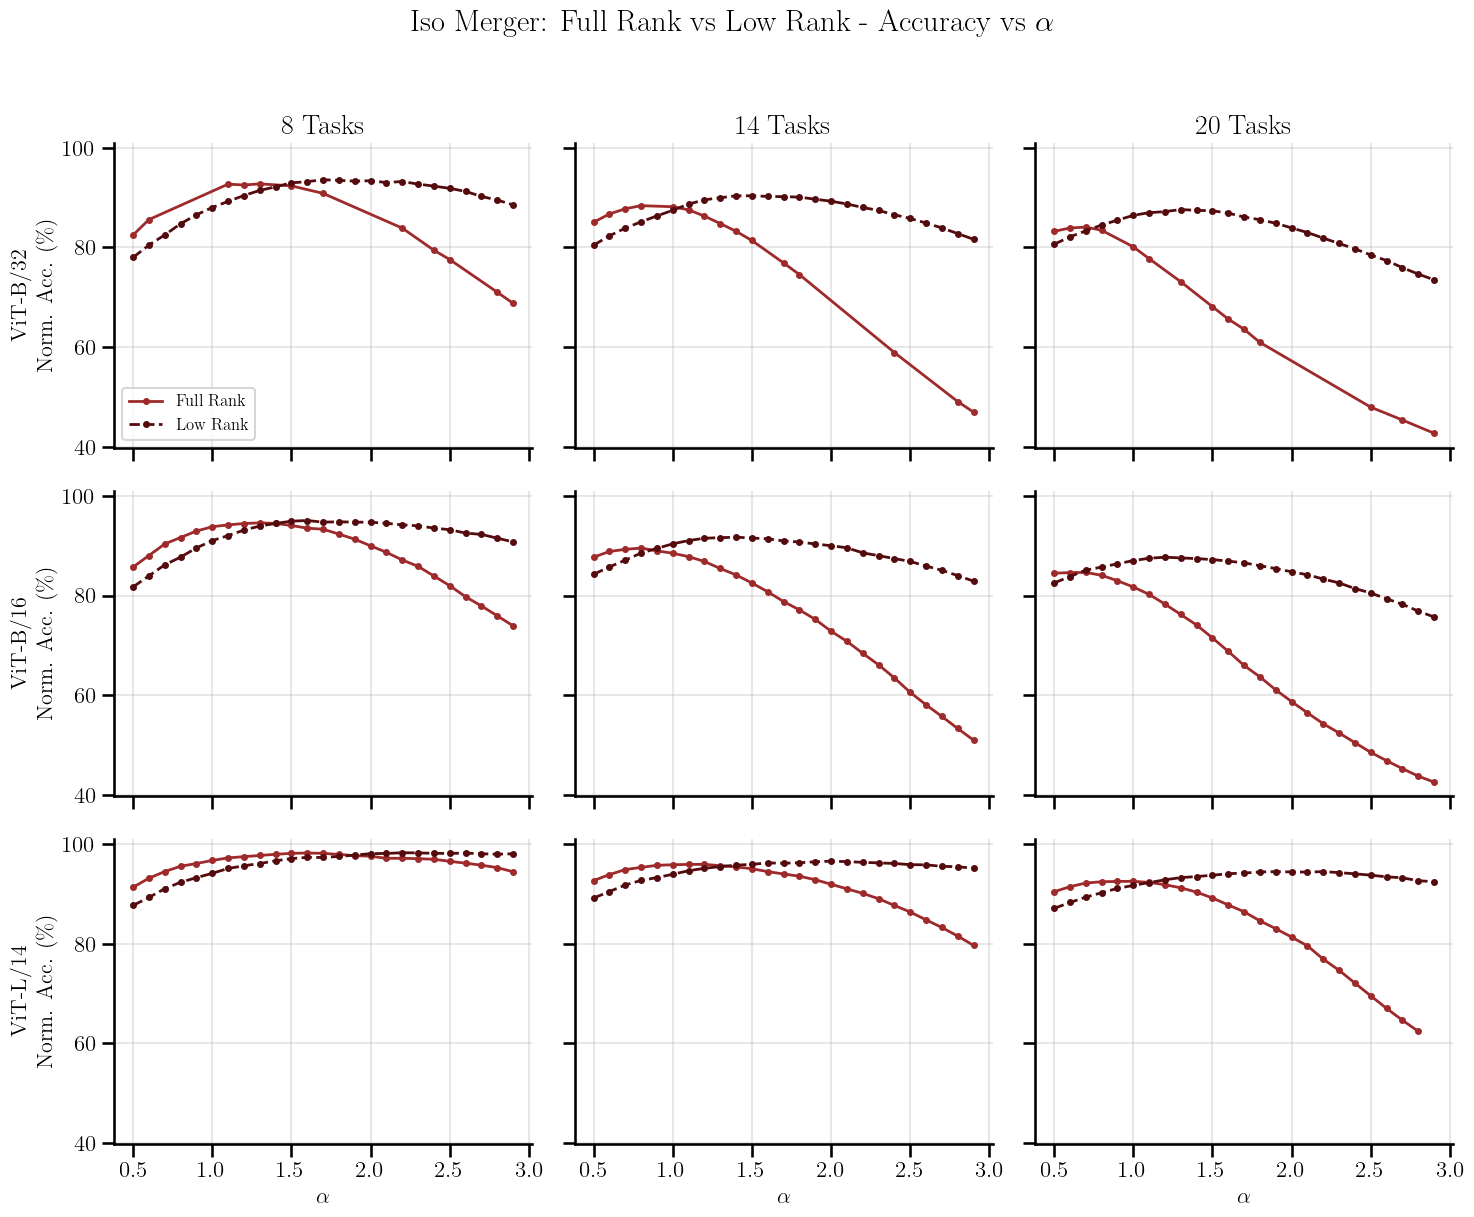

In [13]:
# 3x3 Grid: Scaling Coefficient Sweep (Model × Benchmark)
models = ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
rank_types = ['full_rank', 'low_rank']
num_tasks_list = [8, 14, 20]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for row_idx, model in enumerate(models):
    for col_idx, num_tasks in enumerate(num_tasks_list):
        ax = axes[row_idx, col_idx]
        
        for rank_type in rank_types:
            # Filter data for this combination
            mask = (df['model_name'] == model) & (df['num_tasks'] == num_tasks) & (df['rank_type'] == rank_type)
            subset = df[mask].dropna(subset=['alpha', 'norm_acc'])
            
            if not subset.empty:
                # Sort by alpha for proper line plotting
                subset = subset.sort_values('alpha')
                
                ax.plot(subset['alpha'], subset['norm_acc'] * 100,
                        marker='o', linewidth=2, markersize=4,
                        label=MERGER_LABELS.get(rank_type, rank_type),
                        color=MERGER_COLORS.get(rank_type, 'gray'),
                        linestyle='-' if rank_type == 'full_rank' else '--')
        
        # Set title only for top row
        if row_idx == 0:
            ax.set_title(f'{num_tasks} Tasks', fontsize=20)
        
        # Set ylabel only for left column
        if col_idx == 0:
            ax.set_ylabel(f'{MODEL_LABELS.get(model, model)}\nNorm. Acc. (\\%)', fontsize=16)
        
        # Set xlabel only for bottom row
        if row_idx == len(models) - 1:
            ax.set_xlabel(r'$\alpha$', fontsize=16)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.3)
        
        # Add legend only to first subplot
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='best', fontsize=12)

plt.suptitle(f'{merger.capitalize()} Merger: Full Rank vs Low Rank - Accuracy vs $\\alpha$', fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig(f'{merger}_full_vs_low_rank_grid.pdf', bbox_inches='tight')
plt.show()

In [14]:
# Extract best-performing alpha for each rank_type/model/num_tasks combination
best_alphas = df.loc[df.groupby(['rank_type', 'model_name', 'num_tasks'])['norm_acc'].idxmax()]
best_alphas = best_alphas[['rank_type', 'model_name', 'num_tasks', 'alpha', 'norm_acc']].sort_values(
    ['rank_type', 'model_name', 'num_tasks']
)

print("Best alphas for each combination:")
display(best_alphas)

# Format as nested dict for each rank_type (YAML-style output)
models = ['ViT-B-32', 'ViT-B-16', 'ViT-L-14']
rank_types = ['full_rank', 'low_rank']
num_tasks_list = [8, 14, 20]

for rank_type in rank_types:
    print(f"\n# DUAL {rank_type.upper()} optimal_alphas:")
    rank_data = best_alphas[best_alphas['rank_type'] == rank_type]
    
    result = {}
    for model in models:
        model_data = rank_data[rank_data['model_name'] == model]
        result[model] = {}
        for _, row in model_data.iterrows():
            result[model][str(int(row['num_tasks']))] = {
                'alpha': round(row['alpha'], 1),
                'acc': round(row['norm_acc'] * 100, 2)
            }
    
    # Print in YAML format with accuracy
    for model in models:
        print(f"  {model}:")
        for nt in num_tasks_list:
            nt_str = str(nt)
            if nt_str in result[model]:
                alpha = result[model][nt_str]['alpha']
                acc = result[model][nt_str]['acc']
                print(f"    '{nt_str}': {alpha}  # acc: {acc}%")

Best alphas for each combination:


,rank_type,model_name,num_tasks,alpha,norm_acc
39,full_rank,ViT-B-16,8,1.3,0.945829
65,full_rank,ViT-B-16,14,0.8,0.895188
45,full_rank,ViT-B-16,20,0.7,0.846280
92,full_rank,ViT-B-32,8,1.3,0.927463
110,full_rank,ViT-B-32,14,0.8,0.883686
113,full_rank,ViT-B-32,20,0.7,0.840764
187,full_rank,ViT-L-14,8,1.6,0.981866
142,full_rank,ViT-L-14,14,1.2,0.959088
154,full_rank,ViT-L-14,20,1.0,0.925062
307,low_rank,ViT-B-16,8,1.6,0.950507



# DUAL FULL_RANK optimal_alphas:
  ViT-B-32:
    '8': 1.3  # acc: 92.75%
    '14': 0.8  # acc: 88.37%
    '20': 0.7  # acc: 84.08%
  ViT-B-16:
    '8': 1.3  # acc: 94.58%
    '14': 0.8  # acc: 89.52%
    '20': 0.7  # acc: 84.63%
  ViT-L-14:
    '8': 1.6  # acc: 98.19%
    '14': 1.2  # acc: 95.91%
    '20': 1.0  # acc: 92.51%

# DUAL LOW_RANK optimal_alphas:
  ViT-B-32:
    '8': 1.7  # acc: 93.58%
    '14': 1.5  # acc: 90.35%
    '20': 1.3  # acc: 87.59%
  ViT-B-16:
    '8': 1.6  # acc: 95.05%
    '14': 1.4  # acc: 91.7%
    '20': 1.2  # acc: 87.69%
  ViT-L-14:
    '8': 2.2  # acc: 98.24%
    '14': 2.0  # acc: 96.55%
    '20': 2.2  # acc: 94.45%
